
# 04 — XOR Network: The Classic Challenge
**Repo:** [LLM-from-Scratch](https://github.com/sarzara/LLM-from-Scratch) | Section: 01 Neural Networks

## Why XOR?

XOR is the **classic proof** that neural networks can learn what a single straight line cannot.

| x1 | x2 | output | meaning |
|----|----|--------|---------|
| 0  | 0  | **0**  | same inputs |
| 0  | 1  | **1**  | different inputs |
| 1  | 0  | **1**  | different inputs |
| 1  | 1  | **0**  | same inputs |

You cannot draw a single straight line to separate the 0s from the 1s.  
A neural network with one hidden layer solves it perfectly.

**This notebook puts together everything from notebooks 01-03.**



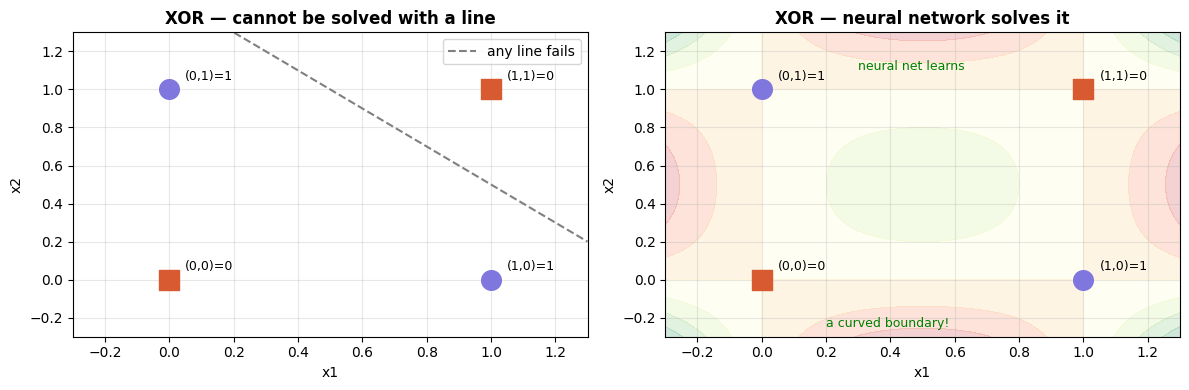

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Why XOR is hard for a single line ────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# XOR data points
points = [(0,0,0), (0,1,1), (1,0,1), (1,1,0)]

for ax, title in zip(axes, ['XOR — cannot be solved with a line', 'XOR — neural network solves it']):
    for x1, x2, label in points:
        color = '#7F77DD' if label == 1 else '#D85A30'
        marker = 'o' if label == 1 else 's'
        ax.scatter(x1, x2, c=color, s=200, marker=marker, zorder=3)
        ax.text(x1+0.05, x2+0.05, f'({x1},{x2})={label}', fontsize=9)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)

# show a line that fails
x_line = np.linspace(-0.3, 1.3, 100)
axes[0].plot(x_line, 0.5 - x_line + 1, 'gray', linestyle='--', label='any line fails')
axes[0].legend()

# show a curved decision boundary (what neural net learns)
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 100), np.linspace(-0.3, 1.3, 100))
axes[1].contourf(xx, yy, xx*yy*(1-xx)*(1-yy), alpha=0.2, cmap='RdYlGn')
axes[1].text(0.3, 1.1, 'neural net learns', color='green', fontsize=9)
axes[1].text(0.2, -0.25, 'a curved boundary!', color='green', fontsize=9)

plt.tight_layout()
plt.savefig('xor_problem.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── The XOR Network ───────────────────────────────────────
# Architecture: 2 inputs -> 4 hidden (sigmoid) -> 1 output (sigmoid)

# activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# XOR data
X = np.array([[0,0], [0,1], [1,0], [1,1]])   # 4 samples, 2 inputs
y = np.array([[0], [1], [1], [0]])             # XOR outputs

print('XOR Training Data:')
print(f"{'Input':^12} | {'Correct Output':^14}")
print('-' * 30)
for xi, yi in zip(X, y):
    print(f"  {xi}  |        {yi[0]}")

XOR Training Data:
   Input     | Correct Output
------------------------------
  [0 0]  |        0
  [0 1]  |        1
  [1 0]  |        1
  [1 1]  |        0


In [ ]:
# ── Initialize weights ────────────────────────────────────

np.random.seed(42)

# layer 1 weights: shape (2, 4) because 2 inputs -> 4 hidden neurons
# each hidden neuron needs a weight for EACH input
W1 = np.random.randn(2, 4)
b1 = np.zeros((1, 4))

# layer 2 weights: shape (4, 1) because 4 hidden -> 1 output
W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

lr = 1.0        # learning rate
epochs = 10000  # number of training iterations

print(f'W1 shape: {W1.shape}  <- (2 inputs, 4 hidden neurons)')
print(f'W2 shape: {W2.shape}  <- (4 hidden, 1 output)')
print(f'Learning rate: {lr}')
print(f'Epochs: {epochs}')

W1 shape: (2, 4)  <- (2 inputs, 4 hidden neurons)
W2 shape: (4, 1)  <- (4 hidden, 1 output)
Learning rate: 1.0
Epochs: 10000


In [ ]:
# ── Training Loop ─────────────────────────────────────────

loss_history = []

for epoch in range(epochs):

    # FORWARD PASS: data flows left to right through the network
    z1 = X @ W1 + b1      # shape: (4, 4) -- 4 samples, 4 hidden neurons
    a1 = sigmoid(z1)       # activation hidden layer
    z2 = a1 @ W2 + b2     # shape: (4, 1) -- 4 samples, 1 output each
    a2 = sigmoid(z2)       # final prediction

    # LOSS: how wrong are we?
    loss = np.mean((y - a2) ** 2)
    loss_history.append(loss)

    # BACKWARD PASS: error flows right to left
    dL_da2 = -2 * (y - a2) / len(y)
    dL_dz2 = dL_da2 * sigmoid_derivative(z2)
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)

    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * sigmoid_derivative(z1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # UPDATE WEIGHTS: move in direction that reduces loss
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}  |  Loss: {loss:.6f}')

print(f'\nFinal Loss: {loss:.6f}')

Epoch     0  |  Loss: 0.283190
Epoch  2000  |  Loss: 0.002784
Epoch  4000  |  Loss: 0.000773
Epoch  6000  |  Loss: 0.000415
Epoch  8000  |  Loss: 0.000276

Final Loss: 0.000204


In [ ]:
# ── Test Results ──────────────────────────────────────────

# final forward pass with trained weights
z1 = X @ W1 + b1
a1 = sigmoid(z1)
z2 = a1 @ W2 + b2
a2 = sigmoid(z2)

print('Results after training:')
print(f"{'Input':^12} | {'Correct':^8} | {'Predicted':^10} | {'Rounded':^8} | {'Pass'}")
print('-' * 55)

all_correct = True
for i in range(4):
    pred    = a2[i][0]
    rounded = round(pred)
    correct = y[i][0]
    passed  = '✓' if rounded == correct else '✗'
    if rounded != correct:
        all_correct = False
    print(f"  {X[i]}    |    {correct}    |   {pred:.4f}   |    {rounded}    |  {passed}")

print(f'\nAll correct: {all_correct}')
print(f'Final loss:  {np.mean((y - a2)**2):.6f}')

Results after training:
   Input     | Correct  | Predicted  | Rounded  | Pass
-------------------------------------------------------
  [0 0]    |    0    |   0.0101   |    0    |  ✓
  [0 1]    |    1    |   0.9871   |    1    |  ✓
  [1 0]    |    1    |   0.9843   |    1    |  ✓
  [1 1]    |    0    |   0.0174   |    0    |  ✓

All correct: True
Final loss:  0.000204


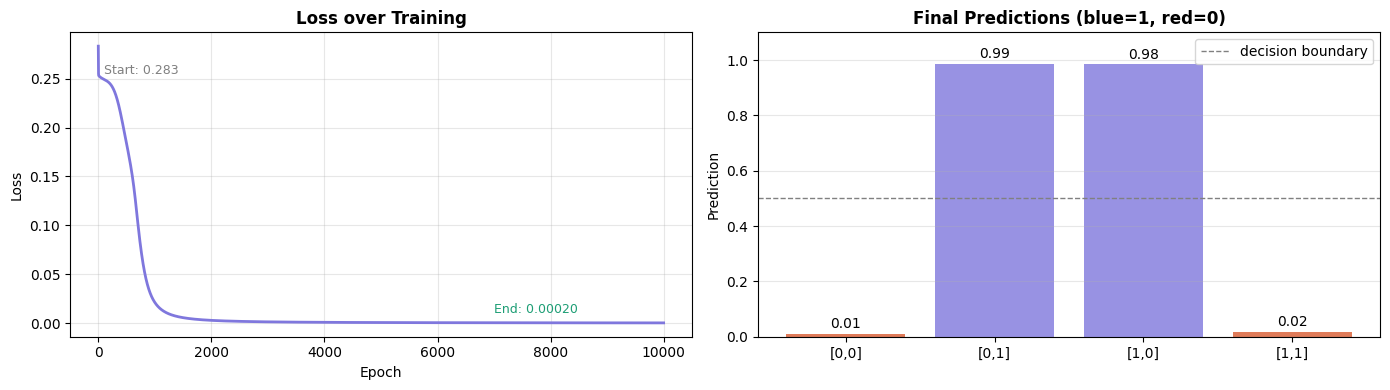

Results saved!


In [ ]:
# ── Plot training progress ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# loss curve
axes[0].plot(loss_history, '#7F77DD', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Training', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].text(100, loss_history[0]*0.9, f'Start: {loss_history[0]:.3f}', fontsize=9, color='gray')
axes[0].text(7000, loss_history[-1]+0.01, f'End: {loss_history[-1]:.5f}', fontsize=9, color='#1D9E75')

# final predictions bar chart
inputs_label = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
bar_colors = ['#D85A30' if r==0 else '#7F77DD' for r in y.flatten()]
axes[1].bar(inputs_label, a2.flatten(), color=bar_colors, alpha=0.8)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='decision boundary')
axes[1].set_ylabel('Prediction')
axes[1].set_title('Final Predictions (blue=1, red=0)', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(a2.flatten()):
    axes[1].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('xor_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Results saved!')

## Summary

The XOR problem proves that:
1. A single layer (linear model) **cannot** solve non-linear problems
2. Adding a hidden layer gives the network the ability to learn curved decision boundaries
3. The training loop (forward → loss → backward → update) works reliably

**What we used from previous notebooks:**
- Neuron formula `z = w·x + b` → notebook 01
- Sigmoid activation function → notebook 02
- Training loop with backprop → notebook 03

**This is the complete foundation of neural networks.**  
GPT, LLaMA, and every other model uses these exact same building blocks — just much larger.

---
**Section 01 complete! ✅**  
**Next section:** `02_nlp_basics/` — How do we turn text into numbers?